# Bitcoin Fraud Detection — GNN + Hybrid Models (Elliptic Dataset)

In [1]:
!pip install pyspark torch-geometric catboost -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.7 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, classification_report

from catboost import CatBoostClassifier

from torch_geometric.data import Data
from torch_geometric.nn import GATConv

## Load & Preprocess

In [3]:
spark = SparkSession.builder.appName("EllipticFraud").getOrCreate()

features_path = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv"
classes_path  = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv"
edges_path    = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv"

features_sdf = spark.read.csv(features_path, inferSchema=True, header=False)
classes_sdf  = spark.read.csv(classes_path,  inferSchema=True, header=True)
edges_sdf    = spark.read.csv(edges_path,    inferSchema=True, header=True)

feature_columns = ["txId", "time_step"] + [f"f_{i}" for i in range(features_sdf.count() - 2)]
feature_columns = ["txId", "time_step"] + [f"f_{i}" for i in range(len(features_sdf.columns) - 2)]
features_sdf = features_sdf.toDF(*feature_columns)

merged_sdf = features_sdf.join(classes_sdf, on="txId", how="inner")
merged_sdf = merged_sdf.filter(col("class") != "unknown")
merged_sdf = merged_sdf.withColumn("class", when(col("class") == "1", 1).otherwise(0))

df = merged_sdf.toPandas()
print(f"Labelled transactions: {len(df)} | Illicit: {df['class'].sum()} | Licit: {(df['class']==0).sum()}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/20 04:13:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/20 04:14:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Labelled transactions: 46564 | Illicit: 4545 | Licit: 42019


## Temporal Train/Test Split (first 34 timesteps train, last 15 test)

In [4]:
node_ids = df["txId"].unique()
id_map   = {nid: idx for idx, nid in enumerate(node_ids)}
df["node_idx"] = df["txId"].map(id_map)

all_feature_cols   = [c for c in df.columns if c.startswith("f_")]   # 165 features
local_feature_cols = all_feature_cols[:93]                            # first 94 (index 0 = time_step)

X_af = df[all_feature_cols].values.astype(np.float32)
X_lf = df[local_feature_cols].values.astype(np.float32)
y_np = df["class"].astype(int).values
ts   = df["time_step"].values

train_idx = np.where(ts <= 34)[0]
test_idx  = np.where(ts  > 34)[0]

print(f"Train size: {len(train_idx)} | Test size: {len(test_idx)}")
print(f"Train illicit: {y_np[train_idx].sum()} | Test illicit: {y_np[test_idx].sum()}")

Train size: 29894 | Test size: 16670
Train illicit: 3462 | Test illicit: 1083


## Build Graph

In [5]:
edges_pd = edges_sdf.toPandas()
edges_pd = edges_pd[edges_pd["txId1"].isin(id_map) & edges_pd["txId2"].isin(id_map)]

source = edges_pd["txId1"].map(id_map).values
target = edges_pd["txId2"].map(id_map).values
edge_index = torch.tensor([source, target], dtype=torch.long)

X_af_t = torch.tensor(X_af, dtype=torch.float)
y_t    = torch.tensor(y_np, dtype=torch.long)

data = Data(x=X_af_t, edge_index=edge_index, y=y_t)

train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(data.num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx]   = True
data.train_mask = train_mask
data.test_mask  = test_mask

print(data)

Data(x=[46564, 165], edge_index=[2, 36624], y=[46564], train_mask=[46564], test_mask=[46564])


/tmp/ipykernel_57/1265571566.py:6: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  edge_index = torch.tensor([source, target], dtype=torch.long)


## Helper: Evaluate & Report

In [6]:
def report(name, y_true, y_pred):
    print(f"\n{'='*50}")
    print(f"{name}")
    print(classification_report(y_true, y_pred, target_names=["licit", "illicit"], digits=3))
    return f1_score(y_true, y_pred, pos_label=1)

## Baseline: Logistic Regression (LF and AF)

In [7]:
lr_lf = LogisticRegression(max_iter=1000, random_state=42)
lr_lf.fit(X_lf[train_idx], y_np[train_idx])
report("Logistic Regression — LF", y_np[test_idx], lr_lf.predict(X_lf[test_idx]))

lr_af = LogisticRegression(max_iter=1000, random_state=42)
lr_af.fit(X_af[train_idx], y_np[train_idx])
report("Logistic Regression — AF", y_np[test_idx], lr_af.predict(X_af[test_idx]))


Logistic Regression — LF
              precision    recall  f1-score   support

       licit      0.979     0.926     0.952     15587
     illicit      0.403     0.713     0.514      1083

    accuracy                          0.913     16670
   macro avg      0.691     0.820     0.733     16670
weighted avg      0.941     0.913     0.924     16670


Logistic Regression — AF
              precision    recall  f1-score   support

       licit      0.978     0.898     0.936     15587
     illicit      0.323     0.704     0.443      1083

    accuracy                          0.885     16670
   macro avg      0.650     0.801     0.689     16670
weighted avg      0.935     0.885     0.904     16670



0.4427658338175479

## Baseline: Random Forest (LF and AF)

In [8]:
rf_lf = RandomForestClassifier(n_estimators=100, max_features=50, random_state=42, n_jobs=-1)
rf_lf.fit(X_lf[train_idx], y_np[train_idx])
report("Random Forest — LF", y_np[test_idx], rf_lf.predict(X_lf[test_idx]))

rf_af = RandomForestClassifier(n_estimators=100, max_features=50, random_state=42, n_jobs=-1)
rf_af.fit(X_af[train_idx], y_np[train_idx])
report("Random Forest — AF", y_np[test_idx], rf_af.predict(X_af[test_idx]))


Random Forest — LF
              precision    recall  f1-score   support

       licit      0.979     0.992     0.985     15587
     illicit      0.853     0.697     0.767      1083

    accuracy                          0.973     16670
   macro avg      0.916     0.844     0.876     16670
weighted avg      0.971     0.973     0.971     16670


Random Forest — AF
              precision    recall  f1-score   support

       licit      0.981     0.996     0.989     15587
     illicit      0.928     0.723     0.813      1083

    accuracy                          0.978     16670
   macro avg      0.954     0.860     0.901     16670
weighted avg      0.978     0.978     0.977     16670



0.8126621691748832

## Feature Importance — Random Forest (AF)

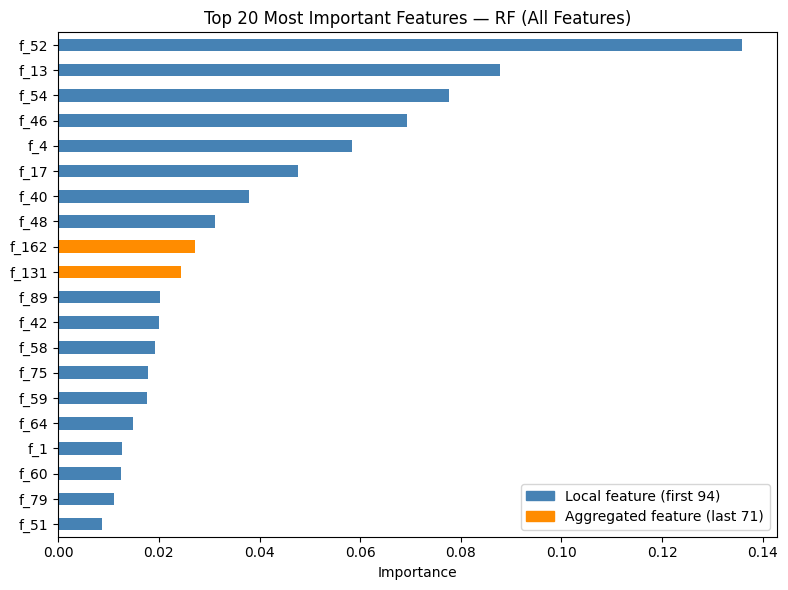

Top 20 breakdown — Local: 18 | Aggregated: 2


In [9]:
importances = pd.Series(rf_af.feature_importances_, index=all_feature_cols)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["steelblue" if c in local_feature_cols else "darkorange" for c in top20.index]
top20.sort_values().plot(kind="barh", ax=ax, color=list(reversed(colors)))

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="steelblue",  label="Local feature (first 94)"),
    Patch(color="darkorange", label="Aggregated feature (last 71)")
], loc="lower right")

ax.set_title("Top 20 Most Important Features — RF (All Features)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

local_in_top20 = sum(c in local_feature_cols for c in top20.index)
agg_in_top20   = sum(c not in local_feature_cols for c in top20.index)
print(f"Top 20 breakdown — Local: {local_in_top20} | Aggregated: {agg_in_top20}")


## Baseline: MLP (LF and AF)

In [10]:
mlp_lf = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
mlp_lf.fit(X_lf[train_idx], y_np[train_idx])
report("MLP — LF", y_np[test_idx], mlp_lf.predict(X_lf[test_idx]))

mlp_af = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
mlp_af.fit(X_af[train_idx], y_np[train_idx])
report("MLP — AF", y_np[test_idx], mlp_af.predict(X_af[test_idx]))


MLP — LF
              precision    recall  f1-score   support

       licit      0.980     0.966     0.973     15587
     illicit      0.592     0.717     0.649      1083

    accuracy                          0.950     16670
   macro avg      0.786     0.842     0.811     16670
weighted avg      0.955     0.950     0.952     16670


MLP — AF
              precision    recall  f1-score   support

       licit      0.976     0.967     0.972     15587
     illicit      0.582     0.664     0.620      1083

    accuracy                          0.947     16670
   macro avg      0.779     0.815     0.796     16670
weighted avg      0.951     0.947     0.949     16670



0.6200948684777922

## Baseline: CatBoost

In [11]:
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="F1",
    class_weights=[1, 5],
    verbose=50,
    random_seed=42
)
cat_model.fit(X_af[train_idx], y_np[train_idx])
report("CatBoost — AF", y_np[test_idx], cat_model.predict(X_af[test_idx]))

0:	learn: 0.9355194	total: 166ms	remaining: 49.6s
50:	learn: 0.9795823	total: 4.08s	remaining: 19.9s
100:	learn: 0.9921920	total: 7.89s	remaining: 15.5s
150:	learn: 0.9976631	total: 11.8s	remaining: 11.7s
200:	learn: 0.9989609	total: 15.8s	remaining: 7.78s
250:	learn: 0.9993938	total: 19.5s	remaining: 3.81s
299:	learn: 0.9996535	total: 23.3s	remaining: 0us

CatBoost — AF
              precision    recall  f1-score   support

       licit      0.982     0.993     0.987     15587
     illicit      0.878     0.736     0.801      1083

    accuracy                          0.976     16670
   macro avg      0.930     0.864     0.894     16670
weighted avg      0.975     0.976     0.975     16670



0.8006027122049222

## Focal Loss

In [12]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction="none")
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1 - pt) ** self.gamma * ce_loss).mean()

## GAT Model

In [13]:
class GATModel(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=4)
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels)
        self.lin   = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        embeddings = self.conv2(x, edge_index)
        out = self.lin(F.elu(embeddings))
        return out, embeddings

## Train GAT

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GATModel(
    in_channels=data.num_node_features,
    hidden_channels=128,
    out_channels=2
).to(device)

data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = FocalLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

def train_step():
    model.train()
    optimizer.zero_grad()
    out, _ = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

for epoch in range(1, 401):
    loss = train_step()
    scheduler.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")

Epoch 020 | Loss: 0.0370
Epoch 040 | Loss: 0.0294
Epoch 060 | Loss: 0.0258
Epoch 080 | Loss: 0.0240
Epoch 100 | Loss: 0.0226
Epoch 120 | Loss: 0.0221
Epoch 140 | Loss: 0.0212
Epoch 160 | Loss: 0.0207
Epoch 180 | Loss: 0.0198
Epoch 200 | Loss: 0.0191
Epoch 220 | Loss: 0.0190
Epoch 240 | Loss: 0.0188
Epoch 260 | Loss: 0.0187
Epoch 280 | Loss: 0.0186
Epoch 300 | Loss: 0.0181
Epoch 320 | Loss: 0.0178
Epoch 340 | Loss: 0.0179
Epoch 360 | Loss: 0.0180
Epoch 380 | Loss: 0.0176
Epoch 400 | Loss: 0.0175


## Focal Loss vs Weighted Cross-Entropy Comparison

Epoch 020 | Focal: 0.0405 | WCE: 0.2296
Epoch 040 | Focal: 0.0297 | WCE: 0.1690
Epoch 060 | Focal: 0.0261 | WCE: 0.1359
Epoch 080 | Focal: 0.0243 | WCE: 0.1155
Epoch 100 | Focal: 0.0228 | WCE: 0.1033
Epoch 120 | Focal: 0.0218 | WCE: 0.0997
Epoch 140 | Focal: 0.0213 | WCE: 0.0947
Epoch 160 | Focal: 0.0207 | WCE: 0.0932
Epoch 180 | Focal: 0.0201 | WCE: 0.0898
Epoch 200 | Focal: 0.0194 | WCE: 0.0866
Epoch 220 | Focal: 0.0191 | WCE: 0.0830
Epoch 240 | Focal: 0.0190 | WCE: 0.0805
Epoch 260 | Focal: 0.0188 | WCE: 0.0813
Epoch 280 | Focal: 0.0184 | WCE: 0.0795
Epoch 300 | Focal: 0.0185 | WCE: 0.0774
Epoch 320 | Focal: 0.0184 | WCE: 0.0756
Epoch 340 | Focal: 0.0181 | WCE: 0.0744
Epoch 360 | Focal: 0.0182 | WCE: 0.0750
Epoch 380 | Focal: 0.0180 | WCE: 0.0719
Epoch 400 | Focal: 0.0181 | WCE: 0.0740


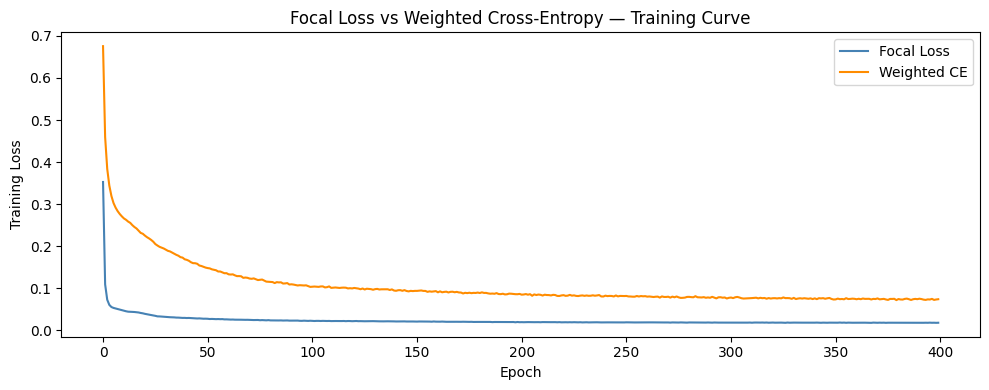


GAT — Weighted Cross-Entropy
              precision    recall  f1-score   support

       licit      0.975     0.956     0.965     15587
     illicit      0.502     0.641     0.563      1083

    accuracy                          0.935     16670
   macro avg      0.738     0.798     0.764     16670
weighted avg      0.944     0.935     0.939     16670


GAT — Focal Loss
              precision    recall  f1-score   support

       licit      0.974     0.951     0.963     15587
     illicit      0.477     0.640     0.547      1083

    accuracy                          0.931     16670
   macro avg      0.726     0.796     0.755     16670
weighted avg      0.942     0.931     0.936     16670



0.5467455621301776

In [15]:
model_wce = GATModel(
    in_channels=data.num_node_features,
    hidden_channels=128,
    out_channels=2
).to(device)

model_focal2 = GATModel(
    in_channels=data.num_node_features,
    hidden_channels=128,
    out_channels=2
).to(device)

optimizer_wce    = torch.optim.Adam(model_wce.parameters(),    lr=0.001, weight_decay=5e-4)
optimizer_focal2 = torch.optim.Adam(model_focal2.parameters(), lr=0.001, weight_decay=5e-4)
scheduler_wce    = torch.optim.lr_scheduler.StepLR(optimizer_wce,    step_size=100, gamma=0.5)
scheduler_focal2 = torch.optim.lr_scheduler.StepLR(optimizer_focal2, step_size=100, gamma=0.5)
criterion_wce    = nn.CrossEntropyLoss(weight=torch.tensor([0.3, 0.7]).to(device))
criterion_focal2 = FocalLoss()

wce_losses   = []
focal_losses = []

for epoch in range(1, 401):
    model_wce.train()
    optimizer_wce.zero_grad()
    out_wce, _ = model_wce(data.x, data.edge_index)
    loss_wce = criterion_wce(out_wce[data.train_mask], data.y[data.train_mask])
    loss_wce.backward()
    optimizer_wce.step()
    scheduler_wce.step()
    wce_losses.append(loss_wce.item())

    model_focal2.train()
    optimizer_focal2.zero_grad()
    out_f2, _ = model_focal2(data.x, data.edge_index)
    loss_f2 = criterion_focal2(out_f2[data.train_mask], data.y[data.train_mask])
    loss_f2.backward()
    optimizer_focal2.step()
    scheduler_focal2.step()
    focal_losses.append(loss_f2.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Focal: {focal_losses[-1]:.4f} | WCE: {wce_losses[-1]:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(focal_losses, label="Focal Loss",   color="steelblue")
plt.plot(wce_losses,   label="Weighted CE",  color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Focal Loss vs Weighted Cross-Entropy — Training Curve")
plt.legend()
plt.tight_layout()
plt.show()

model_wce.eval()
model_focal2.eval()
with torch.no_grad():
    out_wce_test, _  = model_wce(data.x,    data.edge_index)
    out_f2_test,  _  = model_focal2(data.x, data.edge_index)

preds_wce    = out_wce_test.argmax(dim=1)[data.test_mask].cpu().numpy()
preds_focal2 = out_f2_test.argmax(dim=1)[data.test_mask].cpu().numpy()
true_labels  = data.y[data.test_mask].cpu().numpy()

report("GAT — Weighted Cross-Entropy", true_labels, preds_wce)
report("GAT — Focal Loss",             true_labels, preds_focal2)


## Evaluate GAT

In [16]:
model.eval()
with torch.no_grad():
    out, embeddings = model(data.x, data.edge_index)
    preds = out.argmax(dim=1)

test_preds  = preds[data.test_mask].cpu().numpy()
test_labels = data.y[data.test_mask].cpu().numpy()
embeddings_np = embeddings.cpu().numpy()

report("GAT", test_labels, test_preds)


GAT
              precision    recall  f1-score   support

       licit      0.974     0.952     0.963     15587
     illicit      0.477     0.634     0.544      1083

    accuracy                          0.931     16670
   macro avg      0.725     0.793     0.754     16670
weighted avg      0.942     0.931     0.936     16670



0.5443740095087163

## Hybrid: GAT Embeddings + Original Features → CatBoost (AF+NE)

In [17]:
X_train_hybrid = np.concatenate([X_af[train_idx], embeddings_np[train_idx]], axis=1)
X_test_hybrid  = np.concatenate([X_af[test_idx],  embeddings_np[test_idx]],  axis=1)

hybrid_cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="F1",
    class_weights=[1, 5],
    verbose=50,
    random_seed=42
)
hybrid_cat.fit(X_train_hybrid, y_np[train_idx])
report("Hybrid GAT+CatBoost — AF+NE", test_labels, hybrid_cat.predict(X_test_hybrid))

hybrid_rf = RandomForestClassifier(n_estimators=100, max_features=50, random_state=42, n_jobs=-1)
hybrid_rf.fit(X_train_hybrid, y_np[train_idx])
report("Hybrid GAT+RandomForest — AF+NE", test_labels, hybrid_rf.predict(X_test_hybrid))

0:	learn: 0.9199871	total: 207ms	remaining: 1m 2s
50:	learn: 0.9829977	total: 7.43s	remaining: 36.3s
100:	learn: 0.9930983	total: 14.7s	remaining: 28.9s
150:	learn: 0.9976631	total: 21.8s	remaining: 21.5s
200:	learn: 0.9990765	total: 28.9s	remaining: 14.2s
250:	learn: 0.9995669	total: 35.9s	remaining: 7.01s
299:	learn: 0.9997690	total: 42.7s	remaining: 0us

Hybrid GAT+CatBoost — AF+NE
              precision    recall  f1-score   support

       licit      0.980     0.987     0.983     15587
     illicit      0.787     0.706     0.745      1083

    accuracy                          0.969     16670
   macro avg      0.883     0.847     0.864     16670
weighted avg      0.967     0.969     0.968     16670


Hybrid GAT+RandomForest — AF+NE
              precision    recall  f1-score   support

       licit      0.980     0.995     0.987     15587
     illicit      0.902     0.706     0.792      1083

    accuracy                          0.976     16670
   macro avg      0.941     0.851 

0.7923355774210253

## Per-Timestep Illicit F1 (Figure 2 equivalent)

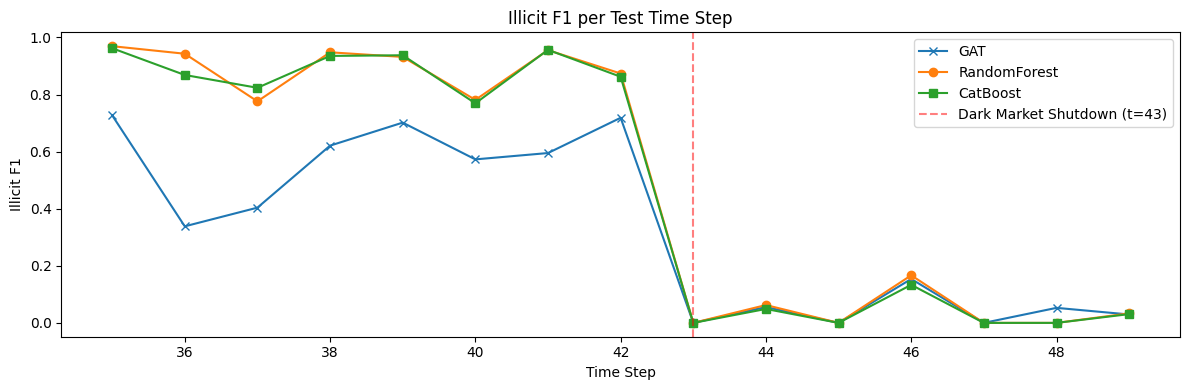

In [18]:
ts_test = ts[test_idx]

gat_f1_per_ts  = {}
rf_f1_per_ts   = {}
cat_f1_per_ts  = {}

for t in sorted(np.unique(ts_test)):
    mask = ts_test == t
    if mask.sum() == 0 or y_np[test_idx][mask].sum() == 0:
        continue
    true = y_np[test_idx][mask]
    gat_f1_per_ts[t]  = f1_score(true, test_preds[mask],                               pos_label=1, zero_division=0)
    rf_f1_per_ts[t]   = f1_score(true, rf_af.predict(X_af[test_idx][mask]),             pos_label=1, zero_division=0)
    cat_f1_per_ts[t]  = f1_score(true, cat_model.predict(X_af[test_idx][mask]),         pos_label=1, zero_division=0)

plt.figure(figsize=(12, 4))
plt.plot(list(gat_f1_per_ts.keys()),  list(gat_f1_per_ts.values()),  label="GAT",          marker="x")
plt.plot(list(rf_f1_per_ts.keys()),   list(rf_f1_per_ts.values()),   label="RandomForest", marker="o")
plt.plot(list(cat_f1_per_ts.keys()),  list(cat_f1_per_ts.values()),  label="CatBoost",     marker="s")
plt.axvline(x=43, color="red", linestyle="--", alpha=0.5, label="Dark Market Shutdown (t=43)")
plt.xlabel("Time Step")
plt.ylabel("Illicit F1")
plt.title("Illicit F1 per Test Time Step")
plt.legend()
plt.tight_layout()
plt.show()

## Summary Table

In [19]:
results = {
    "LR — LF":               f1_score(y_np[test_idx], lr_lf.predict(X_lf[test_idx]),   pos_label=1),
    "LR — AF":               f1_score(y_np[test_idx], lr_af.predict(X_af[test_idx]),   pos_label=1),
    "RF — LF":               f1_score(y_np[test_idx], rf_lf.predict(X_lf[test_idx]),   pos_label=1),
    "RF — AF":               f1_score(y_np[test_idx], rf_af.predict(X_af[test_idx]),   pos_label=1),
    "MLP — LF":              f1_score(y_np[test_idx], mlp_lf.predict(X_lf[test_idx]),  pos_label=1),
    "MLP — AF":              f1_score(y_np[test_idx], mlp_af.predict(X_af[test_idx]),  pos_label=1),
    "CatBoost — AF":         f1_score(y_np[test_idx], cat_model.predict(X_af[test_idx]), pos_label=1),
    "GAT":                   f1_score(test_labels, test_preds,                          pos_label=1),
    "GAT+CatBoost — AF+NE":  f1_score(test_labels, hybrid_cat.predict(X_test_hybrid),  pos_label=1),
    "GAT+RF — AF+NE":        f1_score(test_labels, hybrid_rf.predict(X_test_hybrid),   pos_label=1),
}

summary_df = pd.DataFrame.from_dict(results, orient="index", columns=["Illicit F1"])
summary_df = summary_df.sort_values("Illicit F1", ascending=False)
print(summary_df.to_string(float_format="{:.3f}".format))

                      Illicit F1
RF — AF                    0.813
CatBoost — AF              0.801
GAT+RF — AF+NE             0.792
RF — LF                    0.767
GAT+CatBoost — AF+NE       0.745
MLP — LF                   0.649
MLP — AF                   0.620
GAT                        0.544
LR — LF                    0.514
LR — AF                    0.443


## Save Models

In [20]:
os.makedirs("saved_models", exist_ok=True)

joblib.dump(rf_af,      "saved_models/random_forest_af.pkl")
joblib.dump(rf_lf,      "saved_models/random_forest_lf.pkl")
joblib.dump(hybrid_rf,  "saved_models/hybrid_rf_af_ne.pkl")
cat_model.save_model(   "saved_models/catboost_af.cbm")
hybrid_cat.save_model(  "saved_models/hybrid_catboost_af_ne.cbm")
torch.save(model.state_dict(), "saved_models/gat_model.pth")

zip_path = "elliptic_models.zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for root, _, files in os.walk("saved_models"):
        for f in files:
            zf.write(os.path.join(root, f), arcname=f)

print("Saved:", zip_path)

Saved: elliptic_models.zip
